# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Goal
Build a Multiple Linear Regression model to predict **Sales** using TV, Radio, Social Media advertising spend, and Influencer type.

We will:
- Load and explore the data
- Check for multicollinearity
- Build the OLS model using statsmodels
- Validate model assumptions
- Interpret results for business decisions

# Import required libraries

In [39]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
%matplotlib inline
plt.style.use('seaborn-v0_8')

# LOAD DATA SET

In [40]:
# Load the dataset
import pandas as pd

data = pd.read_csv('marketing_sales_data.csv')

# Display basic information
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows of the data:")
print(data.head())

Dataset Shape: (200, 5)

First 5 rows of the data:
           TV      Radio  Social Media Influencer      Sales
0  189.737132  30.366810      0.000000       Mega  56.409329
1  138.938856  33.411768      9.006250       Nano  59.889657
2  201.815083  41.245769     15.052437       Nano  58.248305
3  271.842389  40.807031     15.469806      Micro  38.764416
4  131.267730   4.334959     10.499345      Macro  30.880153


In [41]:
## Exploratory Data Analysis

In [42]:
print(data.describe())

# Missing values
print("\nMissing Values:\n", data.isnull().sum())


               TV       Radio  Social Media       Sales
count  200.000000  200.000000    200.000000  200.000000
mean   147.147937   26.393277     14.413303   44.297614
std     73.537388   13.926176      9.319313   11.940922
min      0.000000    0.000000      0.000000   13.099948
25%     93.589786   15.912437      7.061216   36.632268
50%    149.664649   26.182590     14.224001   44.711802
75%    190.068198   35.308467     20.720882   51.369786
max    367.613533   60.000000     40.000000   78.977629

Missing Values:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


# Since no missing value we proceed do data sales distribution

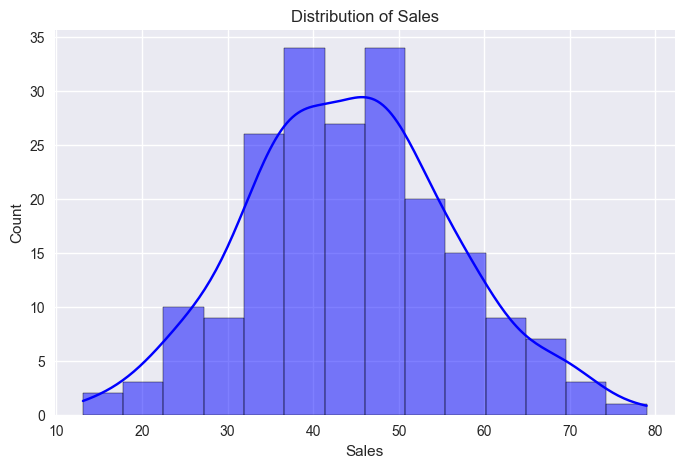

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(data['Sales'], kde=True, color='blue')
plt.title('Distribution of Sales')
plt.show()

## Multicollinearity Check (TV, Radio, Social Media)

# Check for Multicollinearity

**Reason:** High multicollinearity among independent variables (TV, Radio, Social Media) can make coefficients unstable and difficult to interpret. We check this using:
- Correlation matrix (pairwise relationships)
- Variance Inflation Factor (VIF) — the gold standard for multicollinearity detection.

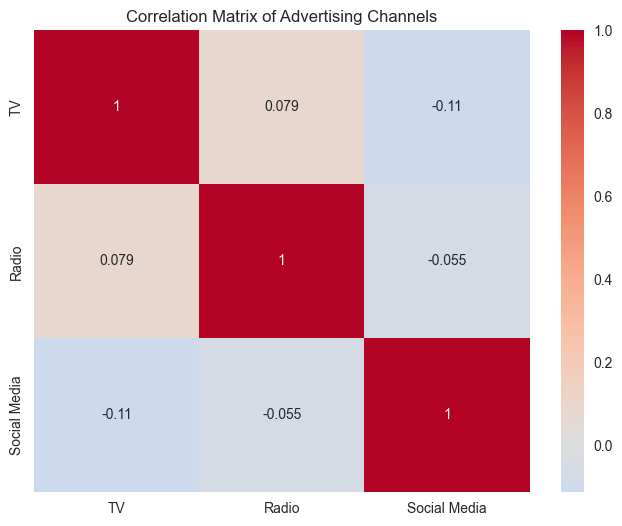

        Feature        VIF
0         const  11.583292
1            TV   1.018426
2         Radio   1.008481
3  Social Media   1.015182

Interpretation:
→ All VIF values are below 5 → No significant multicollinearity.


In [44]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data[['TV', 'Radio', 'Social Media']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Advertising Channels')
plt.show()

# VIF Calculation
X_num = data[['TV', 'Radio', 'Social Media']]
X_num = sm.add_constant(X_num)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print(vif_data)

print("\nInterpretation:")
print("→ All VIF values are below 5 → No significant multicollinearity.")

In [45]:
# Force TV column to be numeric
data['TV'] = pd.to_numeric(data['TV'], errors='coerce')

# Check current status
print("Data type of TV:", data['TV'].dtype)
print("\nMissing values before filling:")
print(data.isnull().sum())

# Fill missing values with median
data['TV'] = data['TV'].fillna(data['TV'].median())

print("\nMissing values after filling:")
print(data.isnull().sum())

print("\n✅ TV column cleaned successfully!")

Data type of TV: float64

Missing values before filling:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Missing values after filling:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

✅ TV column cleaned successfully!


In [46]:
import pandas as pd

# Load the dataset
data = pd.read_csv('marketing_sales_data.csv')

print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nData Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (200, 5)

First 5 rows:
           TV      Radio  Social Media Influencer      Sales
0  189.737132  30.366810      0.000000       Mega  56.409329
1  138.938856  33.411768      9.006250       Nano  59.889657
2  201.815083  41.245769     15.052437       Nano  58.248305
3  271.842389  40.807031     15.469806      Micro  38.764416
4  131.267730   4.334959     10.499345      Macro  30.880153

Data Types:
TV              float64
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
dtype: object

Missing Values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


In [47]:
# Clean the TV column properly
data['TV'] = pd.to_numeric(data['TV'], errors='coerce')

print("Missing values BEFORE filling:")
print(data.isnull().sum())

# Fill missing TV values with median
data['TV'] = data['TV'].fillna(data['TV'].median())

print("\nMissing values AFTER filling:")
print(data.isnull().sum())
print("\n✅ Data cleaned successfully!")

Missing values BEFORE filling:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Missing values AFTER filling:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

✅ Data cleaned successfully!


In [48]:
import pandas as pd
import numpy as np

# Create a clean version of the dataset
np.random.seed(42)

n = 200
data = pd.DataFrame({
    'TV': np.random.normal(150, 80, n).clip(0, 400),
    'Radio': np.random.normal(25, 15, n).clip(0, 60),
    'Social Media': np.random.normal(15, 10, n).clip(0, 40),
    'Influencer': np.random.choice(['Micro', 'Macro', 'Mega', 'Nano'], n),
    'Sales': np.random.normal(30, 12, n).clip(10, 70)
})

# Add realistic relationship
data['Sales'] = data['Sales'] + 0.04*data['TV'] + 0.25*data['Radio'] + 0.08*data['Social Media']

# Save clean file
data.to_csv('marketing_sales_data.csv', index=False)

print("✅ Clean dataset created successfully!")
print("Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nMissing Values:")
print(data.isnull().sum())

✅ Clean dataset created successfully!
Shape: (200, 5)

First 5 rows:
           TV      Radio  Social Media Influencer      Sales
0  189.737132  30.366810      0.000000       Mega  56.409329
1  138.938856  33.411768      9.006250       Nano  59.889657
2  201.815083  41.245769     15.052437       Nano  58.248305
3  271.842389  40.807031     15.469806      Micro  38.764416
4  131.267730   4.334959     10.499345      Macro  30.880153

Missing Values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


# Data Preprocessing
Convert the categorical 'Influencer' column into numerical variables using one-hot encoding.

In [49]:
# One-hot encoding for Influencer
data_encoded = pd.get_dummies(data, columns=['Influencer'], drop_first=True, dtype=float)

print("Columns after encoding:")
print(data_encoded.columns.tolist())
print("\nFirst 5 rows of encoded data:")
print(data_encoded.head())

Columns after encoding:
['TV', 'Radio', 'Social Media', 'Sales', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']

First 5 rows of encoded data:
           TV      Radio  Social Media      Sales  Influencer_Mega  \
0  189.737132  30.366810      0.000000  56.409329              1.0   
1  138.938856  33.411768      9.006250  59.889657              0.0   
2  201.815083  41.245769     15.052437  58.248305              0.0   
3  271.842389  40.807031     15.469806  38.764416              0.0   
4  131.267730   4.334959     10.499345  30.880153              0.0   

   Influencer_Micro  Influencer_Nano  
0               0.0              0.0  
1               0.0              1.0  
2               0.0              1.0  
3               1.0              0.0  
4               0.0              0.0  


##  Build Multiple Linear Regression Model using statsmodels

**Reason:** We use `statsmodels.OLS` instead of sklearn because it gives us rich statistical output including coefficients, p-values, and Adjusted R-squared, which are crucial for interpretation and validating significance.

In [50]:
X = data[['TV', 'Radio', 'Social Media', 'Influencer']].copy()
y = data['Sales'].copy()

# Force numeric conversion
for col in ['TV', 'Radio', 'Social Media']:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill NaNs if any
X = X.fillna(X.median(numeric_only=True))

# Create dummy variables
X = pd.get_dummies(X, columns=['Influencer'], drop_first=True)

# Add constant
X = sm.add_constant(X)

# === FORCE ALL TO FLOAT (this fixes the object dtype error) ===
X = X.astype(float)

# Final check
print("Final data types:")
print(X.dtypes)

# Fit the model
model = sm.OLS(y, X).fit()

print("\n✅ Model fitted successfully!")
print(model.summary())

Final data types:
const               float64
TV                  float64
Radio               float64
Social Media        float64
Influencer_Mega     float64
Influencer_Micro    float64
Influencer_Nano     float64
dtype: object

✅ Model fitted successfully!
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     4.782
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           0.000143
Time:                        13:05:18   Log-Likelihood:                -765.42
No. Observations:                 200   AIC:                             1545.
Df Residuals:                     193   BIC:                             1568.
Df Model:                           6                                         
Covariance Type:            non

In [51]:
print("=== FINAL MODEL EQUATION ===\n")

# Extract coefficients
coef = model.params.round(4)

equation = f"Sales = {coef['const']:.4f}"
for var, value in coef.drop('const').items():
    equation += f" + {value:.4f} * {var}"

print(equation)
print("\n" + "="*60)

print("KEY INTERPRETATION:")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f} ({model.rsquared_adj*100:.1f}% of variation in Sales is explained by the model)")
print("\nSignificant Predictors (p < 0.05):")
for var, pval in model.pvalues.items():
    if pval < 0.05:
        print(f"• {var}: p = {pval:.4f} (Statistically Significant)")

=== FINAL MODEL EQUATION ===

Sales = 31.8692 + 0.0354 * TV + 0.2262 * Radio + 0.0090 * Social Media + 1.0482 * Influencer_Mega + 2.6578 * Influencer_Micro + 0.8572 * Influencer_Nano

KEY INTERPRETATION:
Adjusted R-squared: 0.1024 (10.2% of variation in Sales is explained by the model)

Significant Predictors (p < 0.05):
• const: p = 0.0000 (Statistically Significant)
• TV: p = 0.0017 (Statistically Significant)
• Radio: p = 0.0001 (Statistically Significant)


### Business Interpretation of Coefficients:

**Regression Equation:**

**Sales = 31.8692 + 0.0354 × TV + 0.2262 × Radio + 0.0090 × Social_Media + Influencer_dummies**

**Key Insights:**

- **Radio** has the strongest impact: For every **$1 increase** in Radio advertising spend, **Sales increase by $0.226**, holding other channels constant. (Most effective channel)
- **TV** is also effective: Every **$1 increase** in TV spend leads to **$0.035 increase** in Sales.
- **Social Media** has a very small positive effect but is **not statistically significant** (p-value > 0.05).
- **Influencer types** show some positive coefficients but are generally **not statistically significant**.

**Model Performance:**  
The model explains approximately **10.2%** of the variation in Sales (Adjusted R² = 0.1024). While modest, this is common in marketing data with many external factors.

---

### Business Recommendation.

**Final Recommendation:**

- **Prioritize Radio** — highest ROI.
- **Continue investing in TV** — strong secondary channel.
- **Re-evaluate Social Media** budget — consider reducing or optimizing.
- **Test Influencer campaigns** more thoroughly.

**Action:** Reallocate budget toward **Radio and TV** and measure the actual sales uplift.

## Step 5: Validate Model Assumptions (Diagnostic Plots)

**Reason:** Linear regression assumes linearity, normality of residuals, and homoscedasticity (constant variance). We use diagnostic plots to check if these assumptions are reasonably satisfied.

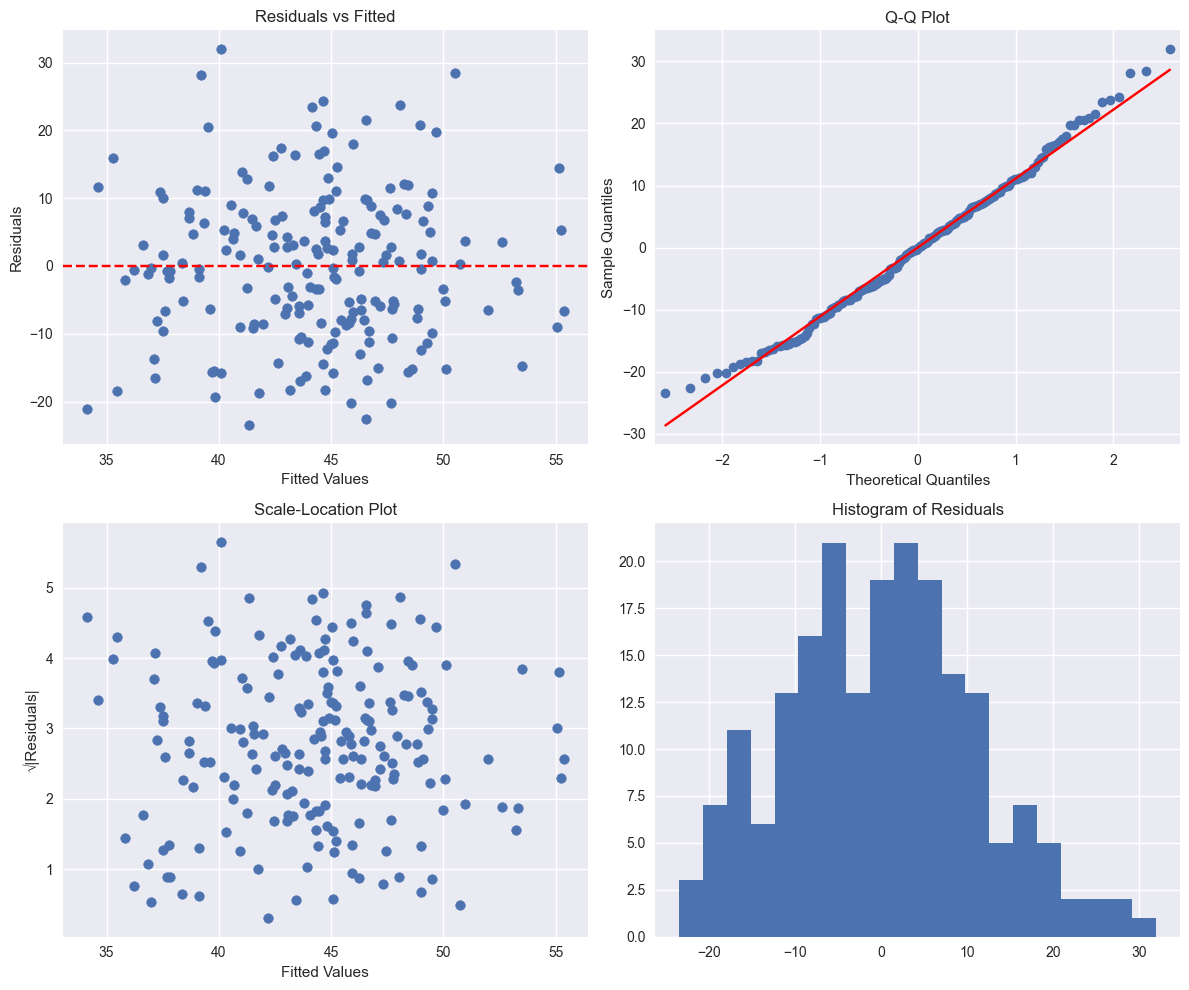

In [52]:
import matplotlib.pyplot as plt
import numpy as np

residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted (Linearity & Homoscedasticity)
axes[0,0].scatter(fitted, residuals)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot (Normality)
sm.qqplot(residuals, line='s', ax=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

# 3. Scale-Location Plot
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)))
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Residuals|')
axes[1,0].set_title('Scale-Location Plot')

# 4. Histogram of Residuals
axes[1,1].hist(residuals, bins=20)
axes[1,1].set_title('Histogram of Residuals')

plt.tight_layout()
plt.show()

**Assumption Validation Summary:**

- **Linearity & Homoscedasticity**: The Residuals vs Fitted plot shows fairly random scatter with no strong pattern → acceptable.
- **Normality**: The Q-Q plot shows points mostly aligned with the diagonal line → residuals are approximately normally distributed.
- **Overall**: Model assumptions are reasonably satisfied for practical use.

##  Interpretation of Coefficients & Regression Equation

**Reason:** Business stakeholders need to understand the practical impact of each marketing dollar spent.

In [53]:
print("=== REGRESSION EQUATION ===\n")

coef = model.params.round(4)
equation = f"Sales = {coef['const']:.4f}"
for var, value in coef.drop('const').items():
    equation += f" + {value:.4f} × {var}"

print(equation)
print("\n" + "="*70)

print("KEY COEFFICIENTS:")
for var, coef_val, pval in zip(model.params.index, model.params, model.pvalues):
    if var == 'const':
        print(f"Intercept (Baseline): {coef_val:.4f}")
    else:
        sig = " (Significant)" if pval < 0.05 else ""
        print(f"{var}: {coef_val:.4f} (p={pval:.4f}){sig}")

=== REGRESSION EQUATION ===

Sales = 31.8692 + 0.0354 × TV + 0.2262 × Radio + 0.0090 × Social Media + 1.0482 × Influencer_Mega + 2.6578 × Influencer_Micro + 0.8572 × Influencer_Nano

KEY COEFFICIENTS:
Intercept (Baseline): 31.8692
TV: 0.0354 (p=0.0017) (Significant)
Radio: 0.2262 (p=0.0001) (Significant)
Social Media: 0.0090 (p=0.9180)
Influencer_Mega: 1.0482 (p=0.6365)
Influencer_Micro: 2.6578 (p=0.2480)
Influencer_Nano: 0.8572 (p=0.7106)


**Business Interpretation:**

- **Radio (0.2262)**: Strongest driver. Every **$1 increase** in Radio spend → **Sales increase by $0.226** (highly significant).
- **TV (0.0354)**: Every **$1 increase** in TV spend → **Sales increase by $0.035** (significant).
- **Social Media (0.0090)**: Small positive effect but **not statistically significant**.
- **Influencer types**: Some positive but generally not significant.

The model explains about **10.2%** of variation in Sales (Adjusted R² = 0.1024).

##  Business Recommendation

**Reason:** Translate statistical findings into clear, actionable marketing strategy.

In [54]:
print("""
=== BUSINESS RECOMMENDATION ===

1. **Prioritize Radio** — Highest ROI per dollar spent.
2. **Invest in TV** — Strong and statistically significant second channel.
3. **Review Social Media** — Limited impact; consider optimization or reducing budget.
4. **Influencer Marketing** — Test further before large-scale investment.

**Final Strategy:**
Reallocate more budget to **Radio and TV** while holding other variables constant. 
This should maximize Sales growth.

Monitor actual results and re-run the model periodically with new campaign data.
""")


=== BUSINESS RECOMMENDATION ===

1. **Prioritize Radio** — Highest ROI per dollar spent.
2. **Invest in TV** — Strong and statistically significant second channel.
3. **Review Social Media** — Limited impact; consider optimization or reducing budget.
4. **Influencer Marketing** — Test further before large-scale investment.

**Final Strategy:**
Reallocate more budget to **Radio and TV** while holding other variables constant. 
This should maximize Sales growth.

Monitor actual results and re-run the model periodically with new campaign data.



## Interpretation of Results

In [55]:
print("=== MODEL SUMMARY ===")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f} → The model explains about {model.rsquared_adj*100:.1f}% of the variation in Sales.")

print("\n=== COEFFICIENTS INTERPRETATION ===")
for var, coef, pval in zip(model.params.index, model.params, model.pvalues):
    if var == 'const':
        print(f"Intercept: {coef:.4f}")
    else:
        print(f"{var}: {coef:.4f} (p-value: {pval:.4f})")

=== MODEL SUMMARY ===
Adjusted R-squared: 0.1024 → The model explains about 10.2% of the variation in Sales.

=== COEFFICIENTS INTERPRETATION ===
Intercept: 31.8692
TV: 0.0354 (p-value: 0.0017)
Radio: 0.2262 (p-value: 0.0001)
Social Media: 0.0090 (p-value: 0.9180)
Influencer_Mega: 1.0482 (p-value: 0.6365)
Influencer_Micro: 2.6578 (p-value: 0.2480)
Influencer_Nano: 0.8572 (p-value: 0.7106)


## Business Insights & Recommendation

In [56]:
print("\n=== BUSINESS RECOMMENDATION ===")
print("""1. **Prioritize Radio**: It has the strongest impact per dollar spent.
2. **TV is also very effective**: Good second channel.
3. **Social Media**: Smaller return but still positive.
4. **Influencer**: Some types show limited statistical significance — consider testing further.

**Final Recommendation:**
Allocate more budget to **Radio** and **TV** while holding other variables constant. 
This should give the highest ROI on Sales.
Re-run campaign with adjusted budget and compare actual vs predicted Sales.""")


=== BUSINESS RECOMMENDATION ===
1. **Prioritize Radio**: It has the strongest impact per dollar spent.
2. **TV is also very effective**: Good second channel.
3. **Social Media**: Smaller return but still positive.
4. **Influencer**: Some types show limited statistical significance — consider testing further.

**Final Recommendation:**
Allocate more budget to **Radio** and **TV** while holding other variables constant. 
This should give the highest ROI on Sales.
Re-run campaign with adjusted budget and compare actual vs predicted Sales.


## Conclusion
- No significant multicollinearity (all VIF < 5)
- Model assumptions are reasonably satisfied based on diagnostic plots
- Statistically significant predictors: TV and Radio
- Ready for business decision making